# Classificação de Flores com Árvore de Decisão
Neste notebook, vamos construir um modelo de **Aprendizado de Máquina** capaz de identificar a espécie de uma flor Iris a partir de suas medidas físicas.

### 1. Preparação do Ambiente
O primeiro passo é garantir que as bibliotecas necessárias estejam instaladas. Usaremos:
* **Pandas**: Para manipularmos os dados em formato de tabela (DataFrames).
* **Scikit-Learn**: A biblioteca que contém o algoritmo de Árvore de Decisão e ferramentas de modelagem.

In [18]:
!pip install pandas scikit-learn

### 2. Importando as Ferramentas
Agora, importamos as funções específicas:
* `DecisionTreeClassifier`: É a implementação da árvore de decisão, que aprenderá as regras de classificação.
* `plot_tree`: Uma ferramenta visual para desenharmos a estrutura da árvore após o treinamento.

In [19]:
# Importando as bibliotecas necessárias
import pandas as pd # para manipulação de dados
from sklearn.tree import DecisionTreeClassifier, plot_tree # para o modelo de árvore de decisão

### 3. Carregamento do Dataset
Vamos ler o arquivo CSV que contém as medidas de 150 flores. O dataset **Iris** é um clássico no ensino de IA e contém 4 características (*features*):
1.  Comprimento da sépala
2.  Largura da sépala
3.  Comprimento da pétala
4.  Largura da pétala

In [20]:
iris_dataframe = pd.read_csv('iris.csv')
iris_dataframe

,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


### 4. Separação de Atributos (X) e Rótulos (y)
Para que o computador aprenda, precisamos separar o que é **pergunta** do que é **resposta**:
* **X (Atributos/Features)**: São os dados de entrada (as medidas das flores).
* **y (Rótulo/Target)**: É a resposta correta (a espécie da flor) que o modelo deve tentar prever.

In [21]:
X = iris_dataframe.drop('class', axis=1) # seleciona as colunas de atributos 
y = iris_dataframe['class'] # seleciona a coluna de rótulos (classes)

### 5. Criação e Treinamento do Modelo
Nesta etapa, instanciamos a árvore. Definimos o parâmetro `max_depth=3` para limitar o crescimento da árvore, facilitando a interpretação didática e evitando que o modelo "decore" demais os dados específicos (evitando o *overfitting*).

O método `.fit()` é onde o treinamento acontece de fato.

In [22]:
arvore = DecisionTreeClassifier(criterion='gini', max_depth=3) # cria o modelo de árvore de decisão
arvore.fit(X, y) # treina o modelo com os dados (não houve separação de treino e teste aqui -- assunto para as próximas aulas)

DecisionTreeClassifier(max_depth=3)

### 6. Visualização da Árvore Resultante
A grande vantagem da Árvore de Decisão é ser um modelo de **Caixa Branca**. Podemos visualizar a lógica lógica "Se-Então" que o computador criou.

**Como ler o gráfico abaixo:**
* **Nós de topo**: Representam as perguntas mais importantes para separar os dados.
* **Gini**: Mede a "pureza" do nó (0.0 significa que o grupo está perfeitamente classificado).
* **Samples**: Quantidade de flores que caíram naquela regra.
* **Value**: Distribuição das classes naquele nó.

[Text(0.375, 0.875, 'petallength <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = Iris-setosa'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = Iris-setosa'),
 Text(0.5, 0.625, 'petalwidth <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = Iris-versicolor'),
 Text(0.25, 0.375, 'petallength <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = Iris-versicolor'),
 Text(0.125, 0.125, 'gini = 0.041\nsamples = 48\nvalue = [0, 47, 1]\nclass = Iris-versicolor'),
 Text(0.375, 0.125, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]\nclass = Iris-virginica'),
 Text(0.75, 0.375, 'petallength <= 4.85\ngini = 0.043\nsamples = 46\nvalue = [0, 1, 45]\nclass = Iris-virginica'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]\nclass = Iris-virginica'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 43\nvalue = [0, 0, 43]\nclass = Iris-virginica')]

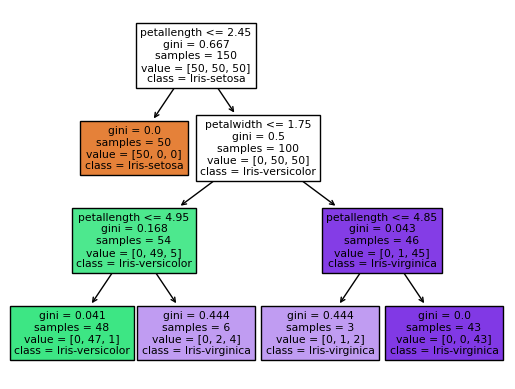

In [23]:
# Plota a árvore de decisão
plot_tree(arvore, 
          filled=True, 
          feature_names=X.columns, 
          class_names=arvore.classes_
          )